In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time 

n_train = 32
n_test = 1_000
ps = np.linspace(0, 1.0, 11)         # proportion p of corrupted labels

# training parameters
epochs = 100_000
lr = 1e-3
early_stop = False
nb_errors_allowed = 0               # early stop if <= this many errors
freq_check = 10                     # check early stop every freq_check epochs

# model parameters
width = 8096
nonlinearity = nn.ReLU() # can also try nn.LeakyReLU(0.1), nn.Tanh(), etc.


# calibration cell:
# goal = check how close we get to interpolation across p, and whether a smaller width is safe before running the repeated-runs cell
widths_calib = [4096, 8096]
epochs_calib = 100_000
freq_check_calib = 50
target_train_err_calib = 0

def run_calibration(width_calib):
    torch.manual_seed(0)
    rng_xtr = np.random.default_rng(4)
    rng_ytr = np.random.default_rng(6)

    rows = []
    t0 = time.time()

    for p in ps:
        xtr = rng_xtr.uniform(-1, 1, (n_train, 1)).astype(np.float32)
        ytr = (xtr[:, 0] > 0).astype(np.float32)[:, None]

        mask_ytr = rng_ytr.choice(n_train, size=int(np.ceil(p * n_train)), replace=False)
        if mask_ytr.size > 0:
            ytr[mask_ytr] = rng_ytr.integers(0, 2, mask_ytr.size).astype(np.float32)[:, None]

        xtr = torch.tensor(xtr)
        ytr = torch.tensor(ytr, dtype=torch.long).squeeze()

        net = nn.Sequential(
            nn.Linear(1, width_calib, bias=True),
            nonlinearity,
            nn.Linear(width_calib, 2, bias=False),
        )

        opt = torch.optim.Adam(net.parameters(), lr=lr)

        best_tr_err = n_train + 1
        best_step = None
        first_zero_step = None
        final_tr_err = None

        for t in range(epochs_calib):
            opt.zero_grad()
            logits = net(xtr)
            loss = F.cross_entropy(logits, ytr)
            loss.backward()
            opt.step()

            if (t % freq_check_calib == 0) or (t == epochs_calib - 1):
                with torch.no_grad():
                    tr_err = int((net(xtr).argmax(dim=1) != ytr).float().sum().item())

                if tr_err < best_tr_err:
                    best_tr_err = tr_err
                    best_step = t

                if (first_zero_step is None) and (tr_err <= target_train_err_calib):
                    first_zero_step = t

                final_tr_err = tr_err

        rows.append({
            'p': float(p),
            'best_tr_err': int(best_tr_err),
            'best_step': int(best_step),
            'first_zero_step': None if first_zero_step is None else int(first_zero_step),
            'final_tr_err': int(final_tr_err),
        })

        zero_txt = '-' if first_zero_step is None else str(first_zero_step)
        print(
            f'width={width_calib:4d}, p={p:>3.1f}: '
            f'best checked err = {best_tr_err:2d} at step {best_step:6d} | '
            f'first checked 0 = {zero_txt:>6} | '
            f'final err = {final_tr_err:2d}'
        )

    best_errs = np.asarray([row['best_tr_err'] for row in rows], dtype=float)
    final_errs = np.asarray([row['final_tr_err'] for row in rows], dtype=float)
    zero_hits = np.asarray([row['first_zero_step'] is not None for row in rows], dtype=bool)
    print('-' * 110)
    print(
        f'width={width_calib:4d}: '
        f'max best checked err over p = {int(best_errs.max())}, '
        f'max final err over p = {int(final_errs.max())}, '
        f'zero reached for {int(zero_hits.sum())} / {len(ps)} values of p, '
        f'elapsed = {time.time() - t0:.1f}s'
    )
    return rows

all_calib = {}
for width_calib in widths_calib:
    print('\n' + '=' * 110)
    rows = run_calibration(width_calib)
    all_calib[width_calib] = rows



width=4096, p=0.0: best checked err =  0 at step     50 | first checked 0 =     50 | final err =  0
width=4096, p=0.1: best checked err =  0 at step    950 | first checked 0 =    950 | final err =  0
width=4096, p=0.2: best checked err =  0 at step  18300 | first checked 0 =  18300 | final err =  0
width=4096, p=0.3: best checked err =  0 at step  39000 | first checked 0 =  39000 | final err =  0
width=4096, p=0.4: best checked err =  0 at step   3100 | first checked 0 =   3100 | final err =  0
width=4096, p=0.5: best checked err =  0 at step  17150 | first checked 0 =  17150 | final err =  0
width=4096, p=0.6: best checked err =  0 at step  59250 | first checked 0 =  59250 | final err =  0
width=4096, p=0.7: best checked err =  2 at step  19300 | first checked 0 =      - | final err =  2
width=4096, p=0.8: best checked err =  0 at step  58400 | first checked 0 =  58400 | final err =  0
width=4096, p=0.9: best checked err =  0 at step  72800 | first checked 0 =  72800 | final err =  0

run 1/5: max checked train err count over p = 2, max stored train err over p = 0.0625, mean stored train err over p = 0.0170
run 2/5: max checked train err count over p = 3, max stored train err over p = 0.0938, mean stored train err over p = 0.0227
run 3/5: max checked train err count over p = 3, max stored train err over p = 0.0938, mean stored train err over p = 0.0227
run 4/5: max checked train err count over p = 2, max stored train err over p = 0.0625, mean stored train err over p = 0.0170
run 5/5: max checked train err count over p = 4, max stored train err over p = 0.1250, mean stored train err over p = 0.0170

elapsed = 992.9s

width=8096, n_runs=5: interpolation summary
max checked train err count over p, averaged over runs = 2.80 +/- 0.75
number of runs with max checked train err count = 0 over all p: 0 / 5
max stored train err over p, averaged over runs = 0.0875 +/- 0.0234

width=8096, n_runs=5: mean rank +/- std (rank by |corr| within each run)
stat                         

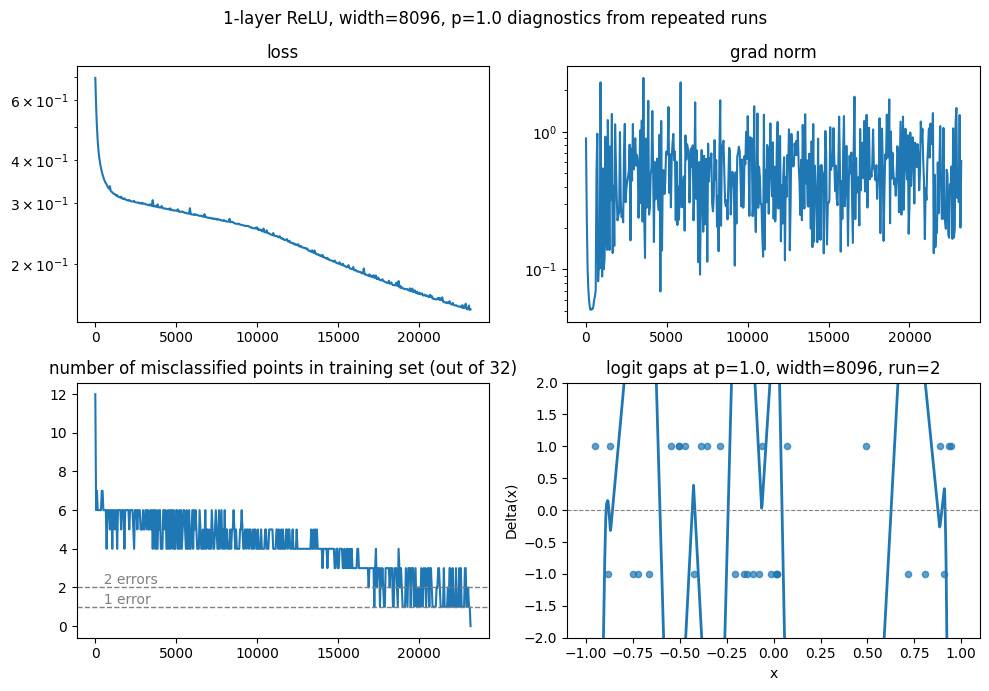

In [2]:
# main experiment cell:
# goal = see which proxies stay near the top across random seeds / training sets
# we keep the best checked iterate (smallest train error seen during training), not just the final iterate at the budget
# we also keep one selected p=1 solution for a diagnostic mosaic at the end

n_runs = 5
width_multi = 8096   # chosen to keep near interpolation on the hard corruption levels
epochs_multi = 40_000
freq_check_multi = 50
target_train_err_multi = 0
lr_multi = 1e-3
n_train_multi = 32
n_test_multi = 1_000
ps_multi = np.linspace(0, 1.0, 11)
gammas_multi = [0.1, 0.2, 0.5, 1.0]
nonlinearity_multi = nn.ReLU()

def corr(a, b):
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    if a.size < 2 or b.size != a.size:
        return np.nan
    if np.allclose(a, a[0]) or np.allclose(b, b[0]):
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

def mean_std(a):
    a = np.asarray(a, float)
    return float(np.nanmean(a)), float(np.nanstd(a))

def run_one_experiment(run_id):
    torch.manual_seed(1000 + run_id)
    rng_xtr = np.random.default_rng(4 + 1000 * run_id)
    rng_xte = np.random.default_rng(5 + 1000 * run_id)
    rng_ytr = np.random.default_rng(6 + 1000 * run_id)
    rng_yte = np.random.default_rng(7 + 1000 * run_id)

    train_err, test_err = [], []

    nb_regions_list, nb_flips_list = [], []
    Leb_wrong_list = []
    band_mass_list = {g: [] for g in gammas_multi}

    Lmax_list, Lavg_list, Lavg_flip_list = [], [], []

    flat_rel_list, sam_sharp_list, hess_list = [], [], []
    best_train_err_count_list = []

    maxp_candidate = None

    for p in ps_multi:
        xtr = rng_xtr.uniform(-1, 1, (n_train_multi, 1)).astype(np.float32)
        ytr = (xtr[:, 0] > 0).astype(np.float32)[:, None]

        xte = rng_xte.uniform(-1, 1, (n_test_multi, 1)).astype(np.float32)
        yte = (xte[:, 0] > 0).astype(np.float32)[:, None]

        mask_ytr = rng_ytr.choice(n_train_multi, size=int(np.ceil(p * n_train_multi)), replace=False)
        mask_yte = rng_yte.choice(n_test_multi, size=int(np.ceil(p * n_test_multi)), replace=False)
        if mask_ytr.size > 0:
            ytr[mask_ytr] = rng_ytr.integers(0, 2, mask_ytr.size).astype(np.float32)[:, None]
        if mask_yte.size > 0:
            yte[mask_yte] = rng_yte.integers(0, 2, mask_yte.size).astype(np.float32)[:, None]

        xtr = torch.tensor(xtr)
        ytr = torch.tensor(ytr, dtype=torch.long).squeeze()
        xte = torch.tensor(xte)
        yte = torch.tensor(yte, dtype=torch.long).squeeze()

        net = nn.Sequential(
            nn.Linear(1, width_multi, bias=True),
            nonlinearity_multi,
            nn.Linear(width_multi, 2, bias=False),
        )

        opt = torch.optim.Adam(net.parameters(), lr=lr_multi)

        best_checked_tr_err = n_train_multi + 1
        best_step = None
        best_state = {k: v.detach().clone() for k, v in net.state_dict().items()}

        losses_hist, grad_norms_hist, errs_hist, check_steps_hist = [], [], [], []

        for t in range(epochs_multi):
            opt.zero_grad()
            logits = net(xtr)
            loss = F.cross_entropy(logits, ytr)
            loss.backward()
            opt.step()

            if t % freq_check_multi == 0:
                with torch.no_grad():
                    tr_err_now = (net(xtr).argmax(dim=1) != ytr).float().sum().item()
                    gn2 = 0.0
                    for param in net.parameters():
                        if param.grad is not None:
                            gn2 += (param.grad ** 2).sum().item()

                losses_hist.append(loss.item())
                grad_norms_hist.append(gn2 ** 0.5)
                errs_hist.append(tr_err_now)
                check_steps_hist.append(t)

                if tr_err_now < best_checked_tr_err:
                    best_checked_tr_err = tr_err_now
                    best_step = t
                    best_state = {k: v.detach().clone() for k, v in net.state_dict().items()}
                if tr_err_now <= target_train_err_multi:
                    break

        net.load_state_dict(best_state, strict=True)

        with torch.no_grad():
            tr_err = (net(xtr).argmax(dim=1) != ytr).float().mean().item()
            te_err = (net(xte).argmax(dim=1) != yte).float().mean().item()

        train_err.append(tr_err)
        test_err.append(te_err)
        best_train_err_count_list.append(best_checked_tr_err)

        if np.isclose(p, ps_multi[-1]):
            maxp_candidate = {
                'run_id': int(run_id),
                'best_train_err_count': float(best_checked_tr_err),
                'stored_train_err': float(tr_err),
                'test_err': float(te_err),
                'best_step': int(best_step),
                'losses': np.asarray(losses_hist, dtype=float),
                'grad_norms': np.asarray(grad_norms_hist, dtype=float),
                'errs': np.asarray(errs_hist, dtype=float),
                'check_steps': np.asarray(check_steps_hist, dtype=float),
                'state': {k: v.detach().clone() for k, v in net.state_dict().items()},
                'xtr': xtr.detach().clone(),
                'ytr': ytr.detach().clone(),
            }

        with torch.no_grad():
            w = net[0].weight[:, 0]
            b = net[0].bias
            v = net[2].weight[1, :] - net[2].weight[0, :]

            mask_w = (w.abs() > 1e-12)
            bk = (-b[mask_w] / w[mask_w]).cpu().numpy()
            bk = np.unique(bk[(bk > -1) & (bk < 1)])
            bk = np.concatenate(([-1], bk, [1]))

            nb_regions = len(bk) - 1
            nb_flips = 0
            Leb_wrong = 0.0
            Lmax = 0.0
            Lavg_sum = 0.0
            Lavg_flip_num = 0.0
            Lavg_flip_den = 0.0
            band_mass = {g: 0.0 for g in gammas_multi}

            for i in range(nb_regions):
                l, r = float(bk[i]), float(bk[i + 1])
                seg_len = r - l
                mid = 0.5 * (l + r)
                xmid = torch.tensor(mid, dtype=w.dtype, device=w.device)

                act = ((w * xmid + b) > 0).to(w.dtype)
                m = (v * act * w).sum().item()
                c = (v * act * b).sum().item()
                abs_m = abs(m)

                Lmax = max(Lmax, abs_m)
                Lavg_sum += abs_m * seg_len

                fl, fr = m * l + c, m * r + c
                if fl * fr < -1e-12:
                    nb_flips += 1

                if abs_m > 1e-12:
                    x0 = -c / m
                    if (x0 > l) and (x0 < r):
                        Lavg_flip_num += abs_m * seg_len
                        Lavg_flip_den += seg_len

                cuts = [(l, r)]
                if l < 0 < r:
                    cuts = [(l, 0.0), (0.0, r)]
                for (ll, rr) in cuts:
                    true_sign = (-1 if rr <= -1e-12 else (1 if ll >= 1e-12 else 0))
                    if true_sign == 0:
                        continue

                    if abs_m <= 1e-12:
                        if c * true_sign < -1e-12:
                            Leb_wrong += (rr - ll)
                    else:
                        xz = -c / m
                        if m > 0:
                            pos_subinterval = max(0.0, rr - max(ll, xz))
                        else:
                            pos_subinterval = max(0.0, min(rr, xz) - ll)
                        Leb_wrong += pos_subinterval if true_sign == -1 else (rr - ll - pos_subinterval)

                for g in gammas_multi:
                    if abs_m <= 1e-12:
                        if abs(c) <= g:
                            band_mass[g] += seg_len
                    else:
                        x1 = (-g - c) / m
                        x2 = (g - c) / m
                        lo, hi = (min(x1, x2), max(x1, x2))
                        ll, rr = max(l, lo), min(r, hi)
                        if rr > ll:
                            band_mass[g] += (rr - ll)

            Lavg = Lavg_sum / 2.0
            Lavg_flip = (Lavg_flip_num / Lavg_flip_den) if (Lavg_flip_den > 0) else 0.0

        nb_regions_list.append(nb_regions)
        nb_flips_list.append(nb_flips)
        Leb_wrong_list.append(Leb_wrong)
        Lmax_list.append(Lmax)
        Lavg_list.append(Lavg)
        Lavg_flip_list.append(Lavg_flip)
        for g in gammas_multi:
            band_mass_list[g].append(band_mass[g])

        with torch.no_grad():
            base_state = {k: v.detach().clone() for k, v in net.state_dict().items()}
        base_loss = F.cross_entropy(net(xtr), ytr).item()

        sigma = 1e-3
        n_samp = 10
        dlosses = []

        for _ in range(n_samp):
            net.load_state_dict(base_state, strict=True)
            with torch.no_grad():
                for param in net.parameters():
                    if param.requires_grad:
                        param.add_(sigma * (param.abs() + 1e-12) * torch.randn_like(param))
            dlosses.append(F.cross_entropy(net(xtr), ytr).item() - base_loss)

        net.load_state_dict(base_state, strict=True)
        flat_rel_list.append(float(np.mean(dlosses)))

        base_state = {k: v.detach().clone() for k, v in net.state_dict().items()}
        loss0 = F.cross_entropy(net(xtr), ytr)
        params = [p for p in net.parameters() if p.requires_grad]
        grads = torch.autograd.grad(loss0, params, create_graph=False)

        gn = torch.sqrt(sum((g.detach() ** 2).sum() for g in grads) + 1e-12)
        rho = 1e-3

        with torch.no_grad():
            for p_, g_ in zip(params, grads):
                p_.add_(rho * g_ / gn)

        loss1 = F.cross_entropy(net(xtr), ytr).item()
        net.load_state_dict(base_state, strict=True)

        sam_sharp_list.append(float(loss1 - loss0.item()))

        params = [p for p in net.parameters() if p.requires_grad]
        loss = F.cross_entropy(net(xtr), ytr)
        grads = torch.autograd.grad(loss, params, create_graph=True)

        v = [torch.randn_like(p) for p in params]
        vn = torch.sqrt(sum((vi ** 2).sum() for vi in v) + 1e-12)
        v = [vi / vn for vi in v]

        lam = 0.0
        n_iter = 10
        for _ in range(n_iter):
            gv = sum((g * vi).sum() for g, vi in zip(grads, v))
            Hv = torch.autograd.grad(gv, params, retain_graph=True)

            num = sum((vi * Hvi).sum() for vi, Hvi in zip(v, Hv))
            den = sum((vi * vi).sum() for vi in v) + 1e-12
            lam = (num / den).item()

            hn = torch.sqrt(sum((Hvi.detach() ** 2).sum() for Hvi in Hv) + 1e-12)
            v = [Hvi.detach() / hn for Hvi in Hv]

        hess_list.append(float(lam))

    stats = {
        'train_err': np.asarray(train_err, dtype=float),
        'nb_regions': np.asarray(nb_regions_list, dtype=float),
        'nb_flips': np.asarray(nb_flips_list, dtype=float),
        'Leb_wrong': np.asarray(Leb_wrong_list, dtype=float),
        'Lmax': np.asarray(Lmax_list, dtype=float),
        'Lavg': np.asarray(Lavg_list, dtype=float),
        'Lavg_flip': np.asarray(Lavg_flip_list, dtype=float),
        **{f'band_mass_{g}': np.asarray(band_mass_list[g], dtype=float) for g in gammas_multi},
        'flat_rel': np.asarray(flat_rel_list, dtype=float),
        'sam_sharp': np.asarray(sam_sharp_list, dtype=float),
        'hess_top': np.asarray(hess_list, dtype=float),
    }

    generalization_gap = np.asarray(test_err, dtype=float) - np.asarray(train_err, dtype=float)

    corr_dict = {}
    for name, vals in stats.items():
        corr_dict[name] = corr(vals, generalization_gap)

    finite_names = [name for name, r in corr_dict.items() if np.isfinite(r)]
    finite_names.sort(key=lambda name: -abs(corr_dict[name]))

    rank_dict = {name: np.nan for name in corr_dict}
    for rank, name in enumerate(finite_names, start=1):
        rank_dict[name] = float(rank)

    return {
        'corr': corr_dict,
        'rank': rank_dict,
        'max_train_err': float(np.max(train_err)),
        'mean_train_err': float(np.mean(train_err)),
        'max_best_train_err_count': float(np.max(best_train_err_count_list)),
        'maxp_candidate': maxp_candidate,
    }

all_runs = []
t0 = time.time()
for run_id in range(n_runs):
    out = run_one_experiment(run_id)
    all_runs.append(out)
    max_tr = out['max_train_err']
    mean_tr = out['mean_train_err']
    max_best_tr_count = out['max_best_train_err_count']
    print(f'run {run_id + 1}/{n_runs}: max checked train err count over p = {max_best_tr_count:.0f}, max stored train err over p = {max_tr:.4f}, mean stored train err over p = {mean_tr:.4f}')
print(f'\nelapsed = {time.time() - t0:.1f}s')

stat_names = list(all_runs[0]['corr'].keys())
rows_rank = []
rows_corr = []
for name in stat_names:
    ranks = np.asarray([run['rank'][name] for run in all_runs], dtype=float)
    corrs = np.asarray([run['corr'][name] for run in all_runs], dtype=float)
    mean_rank, std_rank = mean_std(ranks)
    mean_corr, std_corr = mean_std(corrs)
    mean_abs_corr, _ = mean_std(np.abs(corrs))
    rows_rank.append((name, mean_rank, std_rank))
    rows_corr.append((name, mean_corr, std_corr, mean_abs_corr))

rows_rank.sort(key=lambda r: (np.inf if not np.isfinite(r[1]) else r[1]))
rows_corr.sort(key=lambda r: (np.inf if not np.isfinite(r[3]) else -r[3]))

max_train_errs = np.asarray([run['max_train_err'] for run in all_runs], dtype=float)
max_best_train_err_counts = np.asarray([run['max_best_train_err_count'] for run in all_runs], dtype=float)

print('\n' + '=' * 110)
print(f'width={width_multi}, n_runs={n_runs}: interpolation summary')
print(f'max checked train err count over p, averaged over runs = {np.mean(max_best_train_err_counts):.2f} +/- {np.std(max_best_train_err_counts):.2f}')
print(f'number of runs with max checked train err count = 0 over all p: {(max_best_train_err_counts == 0).sum()} / {n_runs}')
print(f'max stored train err over p, averaged over runs = {np.mean(max_train_errs):.4f} +/- {np.std(max_train_errs):.4f}')
if np.any(max_best_train_err_counts > 0):
    print('Warning: some runs did not reach zero checked train error for all p. If this persists, increase width or epochs before trusting the ranking table too much.')
print('=' * 110)

print('\n' + '=' * 110)
print(f'width={width_multi}, n_runs={n_runs}: mean rank +/- std (rank by |corr| within each run)')
print('{:<28} {:>20}'.format('stat', 'mean rank +/- std'))
print('-' * 110)
for name, mean_rank, std_rank in rows_rank:
    if np.isfinite(mean_rank):
        cell = f'{mean_rank:.2f} +/- {std_rank:.2f}'
    else:
        cell = 'nan'
    print(f'{name:<28} {cell:>20}')
print('=' * 110)

print('\n' + '=' * 110)
print(f'width={width_multi}, n_runs={n_runs}: mean corr +/- std')
print('{:<28} {:>20}'.format('stat', 'mean corr +/- std'))
print('-' * 110)
for name, mean_corr, std_corr, _ in rows_corr:
    if np.isfinite(mean_corr):
        cell = f'{mean_corr:+.3f} +/- {std_corr:.3f}'
    else:
        cell = 'nan'
    print(f'{name:<28} {cell:>20}')
print('=' * 110)

maxp_candidates = [run['maxp_candidate'] for run in all_runs if run['maxp_candidate'] is not None]
selected_maxp = None
if len(maxp_candidates) > 0:
    maxp_candidates.sort(key=lambda d: (d['best_train_err_count'], d['test_err'], d['run_id']))
    selected_maxp = maxp_candidates[0]
    print('\n' + '=' * 110)
    print('selected p=1.0 diagnostic solution')
    print(
        f'run = {selected_maxp["run_id"] + 1}/{n_runs}, '
        f'best checked train err count = {selected_maxp["best_train_err_count"]:.0f}, '
        f'stored train err = {selected_maxp["stored_train_err"]:.4f}, '
        f'test err = {selected_maxp["test_err"]:.4f}, '
        f'best step = {selected_maxp["best_step"]}'
    )
    print('=' * 110)

if selected_maxp is not None:
    net = nn.Sequential(
        nn.Linear(1, width_multi, bias=True),
        nonlinearity_multi,
        nn.Linear(width_multi, 2, bias=False),
    )
    net.load_state_dict(selected_maxp['state'], strict=True)

    losses = selected_maxp['losses']
    grad_norms = selected_maxp['grad_norms']
    errs = selected_maxp['errs']
    check_steps = selected_maxp['check_steps']
    xtr1 = selected_maxp['xtr']
    ytr1 = selected_maxp['ytr']

    fig, axs = plt.subplots(2, 2, figsize=(10, 7))
    axs = axs.ravel()

    axs[0].plot(check_steps, losses)
    axs[0].set_yscale('log')
    axs[0].set_title('loss')

    axs[1].plot(check_steps, grad_norms)
    axs[1].set_yscale('log')
    axs[1].set_title('grad norm')

    axs[2].plot(check_steps, errs)
    axs[2].set_title(f'number of misclassified points in training set (out of {n_train_multi})')
    axs[2].axhline(1, ls='--', lw=1.0, color='gray')
    axs[2].axhline(2, ls='--', lw=1.0, color='gray')
    axs[2].text(check_steps[0], 1, '  1 error', va='bottom', color='gray')
    axs[2].text(check_steps[0], 2, '  2 errors', va='bottom', color='gray')

    xs = torch.linspace(-1, 1, 800).view(-1, 1)
    logits = net(xs).detach()
    deltas = logits[:, 0] - logits[:, 1]
    axs[3].plot(xs[:, 0].cpu().numpy(), deltas.cpu().numpy(), linewidth=2)
    axs[3].scatter(xtr1[:, 0].cpu().numpy(), 2 * ytr1.cpu().numpy() - 1, s=20, alpha=0.7)
    axs[3].axhline(0.0, color='gray', ls='--', lw=0.8)
    axs[3].set_ylim(-2, 2)
    axs[3].set_title(f'logit gaps at p=1.0, width={width_multi}, run={selected_maxp["run_id"] + 1}')
    axs[3].set_xlabel('x')
    axs[3].set_ylabel('Delta(x)')

    plt.suptitle(f'1-layer ReLU, width={width_multi}, p=1.0 diagnostics from repeated runs')
    plt.tight_layout()
    plt.show()
